# Testování hypotéz pomocí Poissonova rozdělení

Mříme události, které se řídí Poissonovým rozdělením. Hledáme neznámý signál na pozadí známých (nebo nezajímavých) procesů. 

* **Očekávané pozadí ($b$):** 15 událostí
* **Očekávaný signál ($s$):** 5 událostí
* **Skutečně naměřeno ($n_{obs}$):** 25 událostí

Cílem je zjistit, jak moc si můžeme být jisti, že naměřený přebytek událostí není jen náhodná fluktuace pozadí, ale opravdu nový neznámý signál.

In [16]:
import numpy as np
from scipy.stats import poisson, norm
%matplotlib inline
%config InlineBackend.figure_format='retina'

b = 15.0   # Očekávané události pozadí
s = 5.0    # Očekávané události signálu 
n_exp = b + s # Celkové očekávané události (20)
n_obs = 25 # Skutečně naměřené události

## Poissonovo rozdělení a p-hodnota

Pravděpodobnost pozorování přesně $k$ událostí při očekávaném průměru $\lambda$ je:
$$P(N = k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

Pokud není žádná nová fyzika, máme pouze background ($\lambda = 15$). Abychom zjistili, zda je náš výsledek zajímavý, počítáme **p-value**. Pravděpodobnost, že by pozadí vytvořilo náhodnou fluktuací počet událostí, který je stejný nebo větší než to co očekáváme nebo jsme naměřili.

Tu jsme schopni určit pomocí CDF Poissona. Například pro pozorování 25 událostí, když očekáváme pouze pozadí 15, je p-hodnota:
$$p_{obs} = P(N \ge 25 \mid \lambda = 15) = 1 - P(N \le 24 \mid \lambda = 15) = CDF_{\lambda = 15}^{poisson}(24) = 1 - \sum_{k=0}^{24} P(N = k \mid \lambda = 15) $$

In [17]:
# p-hodnota pro očekávaný výsledek (>= 20 událostí) z distribuce pozadí
p_exp = 1 - poisson.cdf(n_exp - 1, mu=b)

# p-hodnota pro skutečně pozorovaný výsledek (>= 25 událostí) z distribuce pozadí
p_obs = 1 - poisson.cdf(n_obs - 1, mu=b)

print(f"Pravděpodobnost >= 20 událostí z pozadí (Očekáváme): {p_exp:.4f}")
print(f"Pravděpodobnost >= 25 událostí z pozadí (Naměřili jsme): {p_obs:.4f}")

Pravděpodobnost >= 20 událostí z pozadí (Očekáváme): 0.1248
Pravděpodobnost >= 25 událostí z pozadí (Naměřili jsme): 0.0112


## Převod na signifikanci

Extrémně malé p-value jsou celkem nešikovné, proto je převedeme na směrodatné odchylky ($\sigma$) normálního rozdělení ($Z$-skóre). 

K tomu slouží **inverzní normální kumulativní distribuční funkce (Percent Point Function - PPF)**. 
Standardní Gaussova křivka je centrovaná přesně na 0. Když do PPF vložíme naakumulovanou pravděpodobnost zleva (např. $1 - p$), funkce nám vrátí souřadnici na ose X. Protože je střed v nule, tato souřadnice přímo udává **symetrickou vzdálenost od středu v jednotkách $\sigma$**. Vyšší hodnota $\sigma$ znamená menší pravděpodobnost náhodné fluktuace pozadí.

Očekávaná signifikance: 1.15 sigma
Pozorovaná signifikance: 2.28 sigma


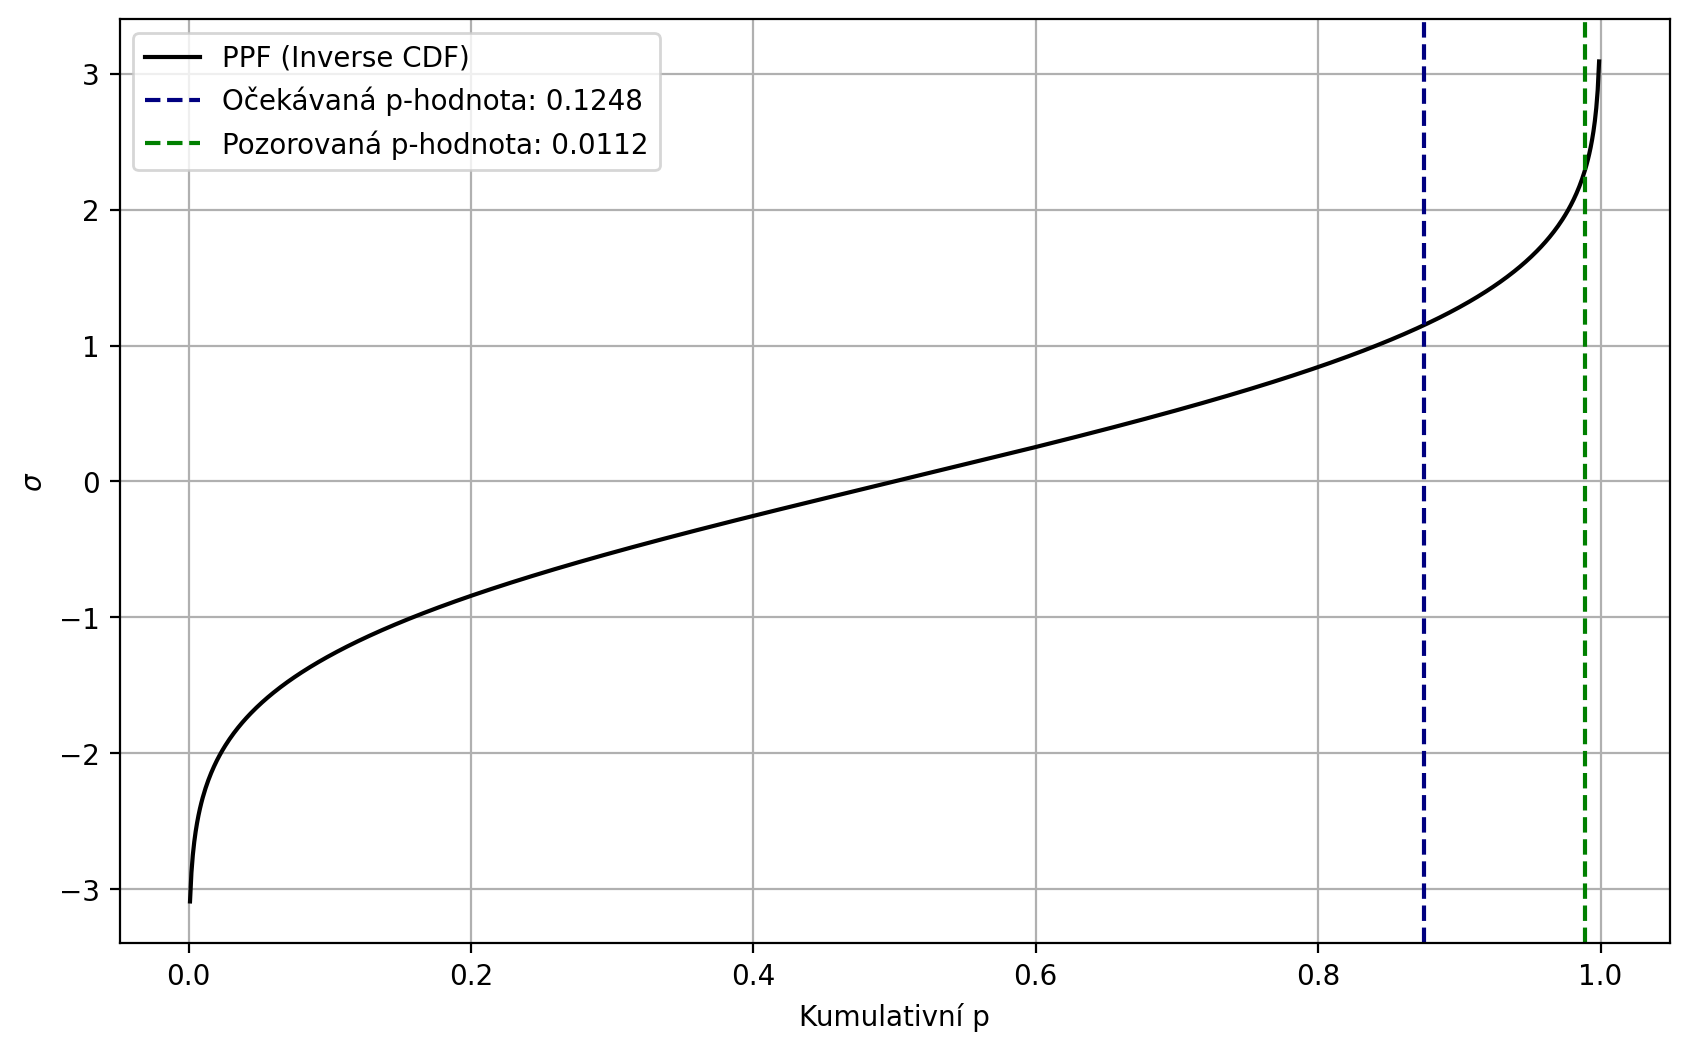

In [22]:
# Převod p-hodnot na Z-skóre pomocí inverzní CDF (norm.ppf)
z_exp = norm.ppf(1 - p_exp)
z_obs = norm.ppf(1 - p_obs)

print(f"Očekávaná signifikance: {z_exp:.2f} sigma")
print(f"Pozorovaná signifikance: {z_obs:.2f} sigma")

plt.figure(figsize=(10, 6))
x = np.linspace(0, 1, 1000)
plt.plot(x, norm.ppf(x), label='PPF (Inverse CDF)', color='k')
plt.axvline(1 - p_exp, color='navy', linestyle='--', label=f'Očekávaná p-hodnota: {p_exp:.4f}')
plt.axvline(1 - p_obs, color='green', linestyle='--', label=f'Pozorovaná p-hodnota: {p_obs:.4f}')
plt.xlabel('Kumulativní p')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid()  
plt.show()

## Luminozita potřebná pro objev

Pro formální objev potřebujeme signifikanci **$5\sigma$**. 

Při zvýšení luminozity $L$ roste signál i pozadí lineárně. Aproximace signifikance je $Z \approx \frac{\text{Signál}}{\sqrt{\text{Pozadí}}}$. Pro novou luminozitu tedy platí:
$$Z_{new} = \sqrt{L} \left( \frac{s}{\sqrt{b}} \right)$$

In [24]:
target_z = 5.0
current_z_approx = s / np.sqrt(b)

# Výpočet potřebného navýšení luminozity L: target_z = sqrt(L) * current_z_approx
sqrt_L = target_z / current_z_approx
L = sqrt_L ** 2

print(f"Pro objev s 5 sigma je potřeba luminozitu zvýšit {L:.1f}x.")

Pro objev s 5 sigma je potřeba luminozitu zvýšit 15.0x.
